In [1]:
# Importing the Libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

In [3]:
# Loading the Dataset
data = pd.read_csv('Website Traffic Forecasting Dataset.csv')

In [5]:
# Analyse the Top 5 rows of the Data
data.head()

,Date,Views
0,01/06/2021,7831
1,02/06/2021,7798
2,03/06/2021,7401
3,04/06/2021,7054
4,05/06/2021,7973


In [7]:
data["Date"] = pd.to_datetime(data["Date"], 
                              format="%d/%m/%Y")
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    391 non-null    datetime64[ns]
 1   Views   391 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 6.2 KB
None


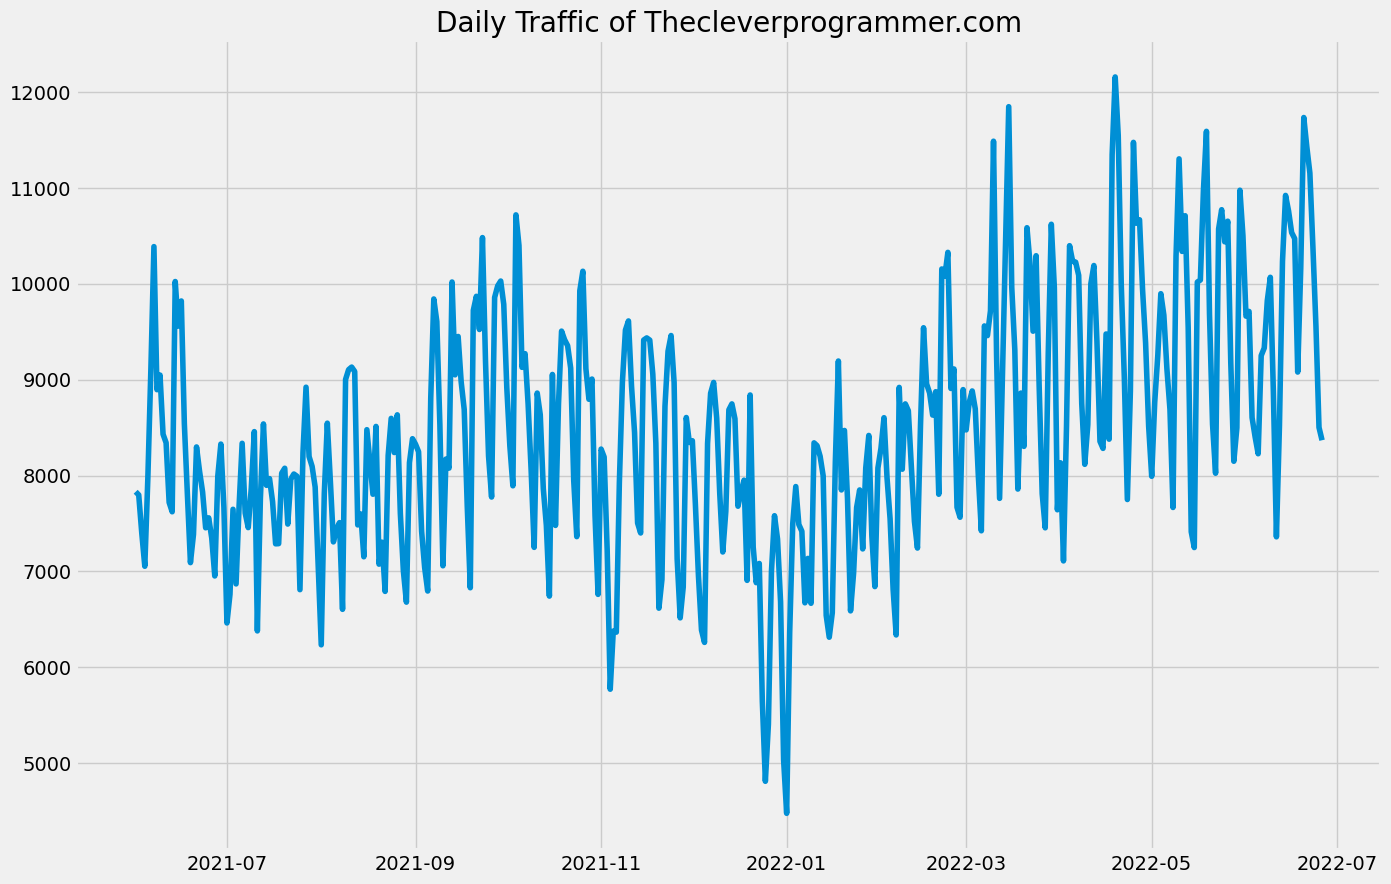

In [9]:
# Now let’s have a look at the daily traffic of the website
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 10))
plt.plot(data["Date"], data["Views"])
plt.title("Daily Traffic of Thecleverprogrammer.com")
plt.show()

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

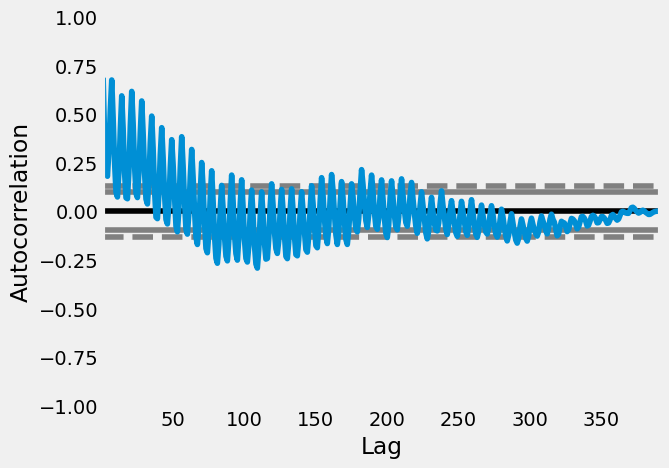

In [17]:
pd.plotting.autocorrelation_plot(data["Views"])

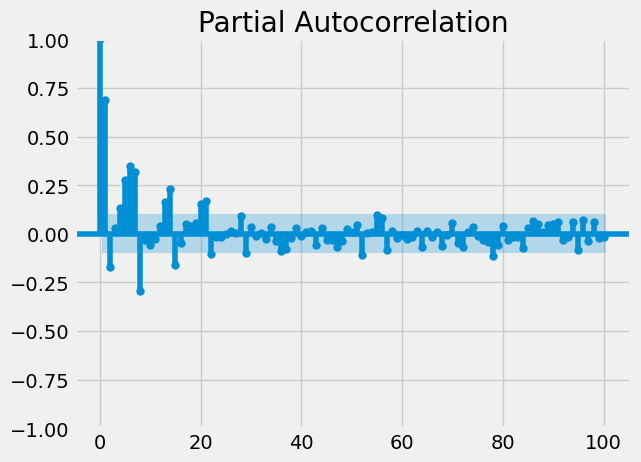

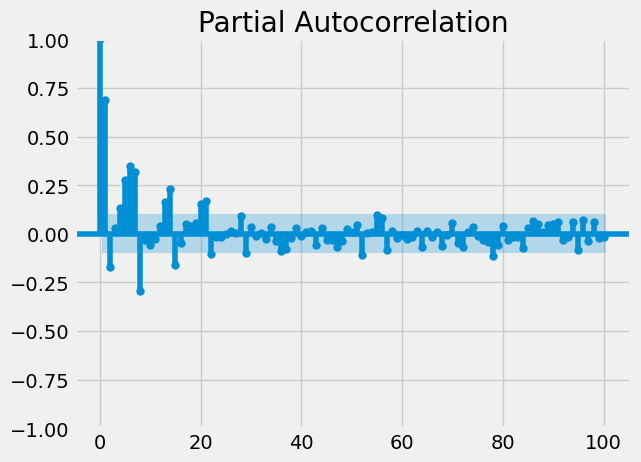

In [19]:
plot_pacf(data["Views"], lags = 100)

In [21]:
p, d, q = 5, 1, 2
model=sm.tsa.statespace.SARIMAX(data['Views'],
                                order=(p, d, q),
                                seasonal_order=(p, d, q, 12))
model=model.fit()
print(model.summary())

C:\Users\irt\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\irt\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              Views   No. Observations:                  391
Model:             SARIMAX(5, 1, 2)x(5, 1, 2, 12)   Log Likelihood               -3098.939
Date:                            Sat, 12 Apr 2025   AIC                           6227.877
Time:                                    16:03:23   BIC                           6286.901
Sample:                                         0   HQIC                          6251.303
                                            - 391                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7714      0.129      5.961      0.000       0.518       1.025
ar.L2         -0.8027      0.135   

In [22]:
predictions = model.predict(len(data), len(data)+50)
print(predictions)

391     9922.665209
392    10829.549835
393    10710.829918
394     9814.609586
395     8750.496190
396     8241.000632
397     8969.546238
398     9762.724139
399    10325.270409
400    10587.077771
401     9868.688285
402     9308.391774
403     9004.737811
404     9109.379098
405    10551.465935
406    11038.920923
407    10930.897579
408    10061.716839
409     9380.629533
410     8614.424700
411     9231.908546
412    10405.880352
413    10688.846425
414    10813.787667
415    10226.334987
416     9366.097363
417     8941.128003
418     9183.738162
419     9978.326147
420    10306.828518
421    10743.659698
422     9867.006807
423     9457.284328
424     8961.855118
425     8910.147841
426    10264.990586
427    10948.326963
428    10924.220085
429    10326.569352
430     9367.023035
431     8684.851380
432     8784.673115
433    10177.079140
434    10625.415753
435    10894.759383
436    10387.320322
437     9271.070234
438     9156.538185
439     9426.237881
440    10407.660960


<Axes: >

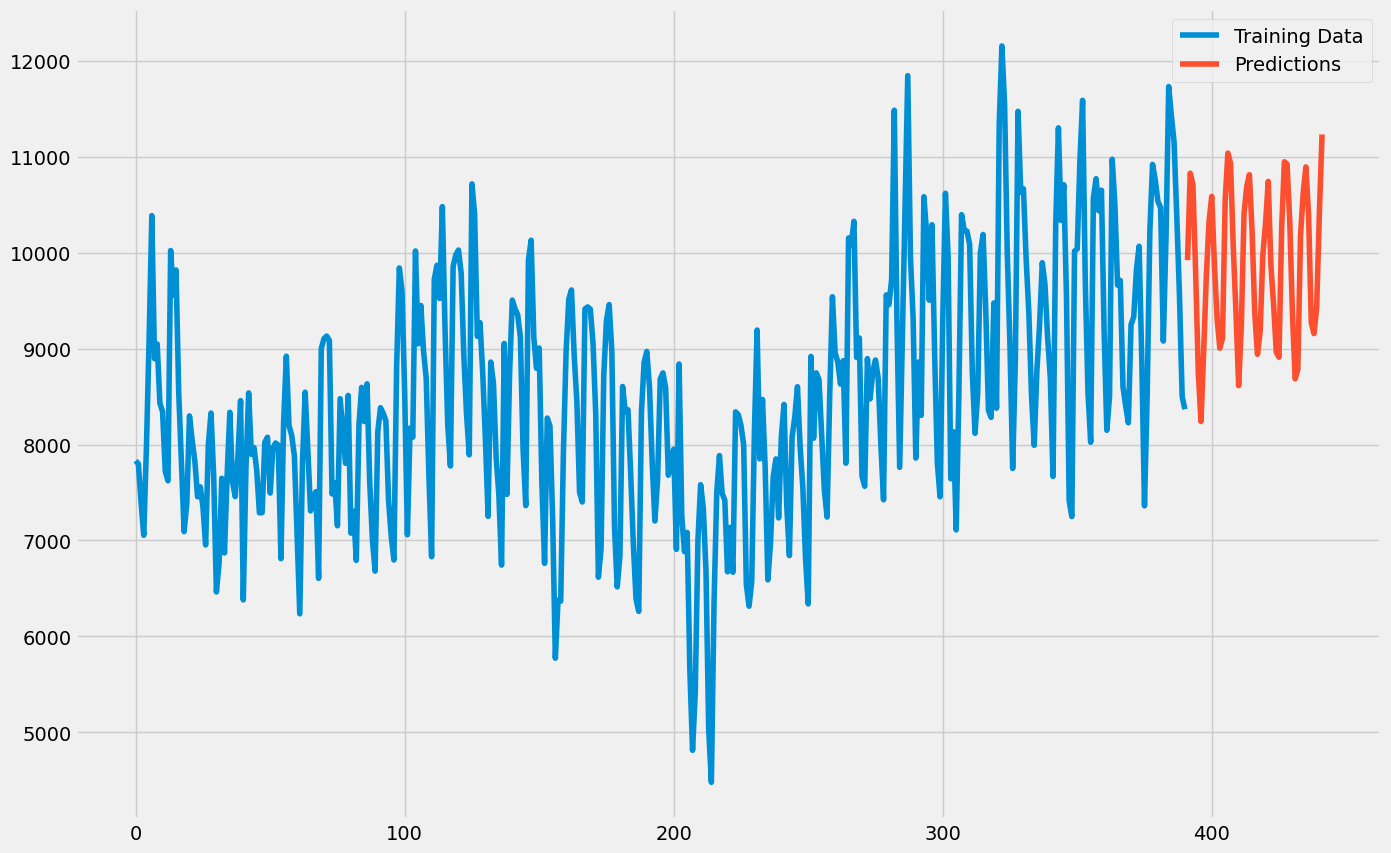

In [23]:
data["Views"].plot(legend=True, label="Training Data", 
                   figsize=(15, 10))
predictions.plot(legend=True, label="Predictions")

#### Summary

 Website traffic prediction is one of the best data science project ideas you can mention on your resume.